In [2]:
#Pandas
import pandas as pd

#graficas
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))
#vectorizacicón de texto
from sklearn.feature_extraction.text import TfidfVectorizer
#División de texto
from sklearn.model_selection import train_test_split

#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

#Json
import json


#url="https://docs.google.com/spreadsheets/d/1QnduVFuFBuuzbTDigcy7RVGuy4FF2d-l8gKWOhrLbyg/export?format=csv&gid=0"
url="https://objectstorage.mx-queretaro-1.oraclecloud.com/p/HQrPnp3oSTEh0FRLJ-1VCupF5j5RfBc68ts_FOVqZobob6-_e7_y5fzT2cnF1BfE/n/axsuszsnqvkf/b/bucket-hackathon/o/Base_datos%20_inicial.csv"

df = pd.read_csv(url)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df.head()

,titulo,texto,categoria
0,Fundamentos de Node.js en el Servidor,Node.js permite crear servidores backend usand...,Backend
1,El Protocolo HTTP en la Web,HTTP es el protocolo que usan los clientes y s...,Backend
2,Principios y Verbos de una API REST,"Una API REST usa verbos como GET, POST, PUT y ...",Backend
3,Ventajas y Configuración de Spring Boot,Spring Boot facilita crear aplicaciones Java a...,Backend
4,Rol del Servidor Backend,Un servidor backend recibe solicitudes y devue...,Backend


#1.Exploración y limpieza de datos (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5320 entries, 0 to 5319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   titulo     5320 non-null   object
 1   texto      5320 non-null   object
 2   categoria  5320 non-null   object
dtypes: object(3)
memory usage: 124.8+ KB


In [5]:
df.columns

Index(['titulo', 'texto', 'categoria'], dtype='object')

##Verificando Datos Nulos O Vacios


In [6]:
df.isnull().sum()

,0
titulo,0
texto,0
categoria,0


In [7]:

# 1. Verificación
nulos_iniciales = df.isnull().sum().sum()
print(f"Cantidad total de nulos detectados: {nulos_iniciales}")

# 2. Aplicar limpieza si existen nulos en columnas críticas
if nulos_iniciales > 0:
    # Elimina filas donde falte el texto o la categoría
    df = df.dropna(subset=['titulo','texto', 'categoria']).reset_index(drop=True)
    print(f"✅ Nulos eliminados. Tamaño actual del dataset: {df.shape}")
else:
    print("✅ No se encontraron nulos.")

Cantidad total de nulos detectados: 0
✅ No se encontraron nulos.


##Verificando Duplicados


In [8]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print(f"Cantidad total de registros duplicados: {duplicados}")

Cantidad total de registros duplicados: 0


##Verificando Formatos


In [9]:
print(df.dtypes)

titulo       object
texto        object
categoria    object
dtype: object


In [10]:
# Eliminar espacios al inicio y al final
df["titulo"] = df["titulo"].str.strip()
df["texto"] = df["texto"].str.strip()
df["categoria"] = df["categoria"].str.strip()

print(" Espacios eliminados.")

 Espacios eliminados.


In [11]:
#Verificando texto (palabras iguales)
print(df["categoria"].unique())


['Backend' 'Frontend' 'BasesDeDatos' 'IA' 'Cloud' 'Fronted'
 'Bases de datos' 'basesdedatos' 'ia' 'cloud' 'backend' 'frontend']


In [12]:
df["categoria"] = df["categoria"].replace({
    "Fronted":"frontend","Frontend":"frontend",
    "Bases de datos":"basesdedatos", "BasesDeDatos":"basesdedatos","Backend":"backend", "IA":"ia", "Cloud":"cloud"
})

In [13]:
print(df["categoria"].unique())

['backend' 'frontend' 'basesdedatos' 'ia' 'cloud']


##Analizando Volumen Del Dataset

In [14]:
print("Dimensiones del dataset:")
print(df.shape)

print(f"\nNúmero de registros: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset:
(5320, 3)

Número de registros: 5320
Número de columnas: 3


In [15]:
#Buscando el balance de categorias
conteo = df["categoria"].value_counts()

print(conteo)

categoria
cloud           1069
basesdedatos    1066
backend         1063
frontend        1062
ia              1060
Name: count, dtype: int64


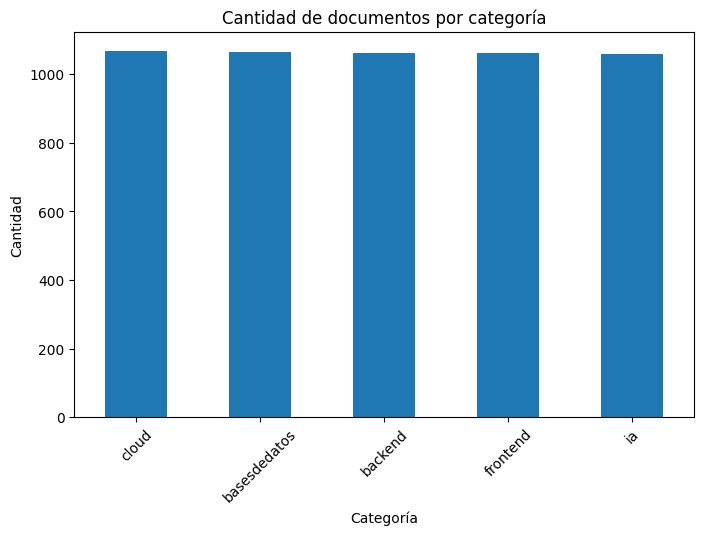

In [16]:


plt.figure(figsize=(8,5))

df["categoria"].value_counts().plot(kind="bar")

plt.title("Cantidad de documentos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

plt.show()

#2.Tratamientos de textos


##Convertir Minusculas


In [17]:
df['texto'] = df['texto'].str.lower()
df['titulo'] = df['titulo'].str.lower()
df['categoria'] = df['categoria'].str.lower()

df.head()

,titulo,texto,categoria
0,fundamentos de node.js en el servidor,node.js permite crear servidores backend usand...,backend
1,el protocolo http en la web,http es el protocolo que usan los clientes y s...,backend
2,principios y verbos de una api rest,"una api rest usa verbos como get, post, put y ...",backend
3,ventajas y configuración de spring boot,spring boot facilita crear aplicaciones java a...,backend
4,rol del servidor backend,un servidor backend recibe solicitudes y devue...,backend


##Eliminacion De Signos De Puntuacion


In [18]:
#Eliminación de signos en textos

df['texto'] = df['texto'].str.replace(r'[^\w\s]|_', '', regex=True)


##Eliminar Stopwords

In [19]:
def eliminar_stopwords(texto):
    if isinstance(texto, str):
        palabras = texto.split()
        palabras_filtradas = [p for p in palabras if p not in stop_words]
        return ' '.join(palabras_filtradas)
    return texto

In [20]:
df['texto']=df['texto'].apply(eliminar_stopwords)

df.head()

,titulo,texto,categoria
0,fundamentos de node.js en el servidor,nodejs permite crear servidores backend usando...,backend
1,el protocolo http en la web,http protocolo usan clientes servidores comuni...,backend
2,principios y verbos de una api rest,api rest usa verbos get post put delete maneja...,backend
3,ventajas y configuración de spring boot,spring boot facilita crear aplicaciones java p...,backend
4,rol del servidor backend,servidor backend recibe solicitudes devuelve r...,backend


#3.Transformación de datos al formato adecuado para modelado

##Definición de variables


In [21]:
# Variables independientes (Texto)
x = df['titulo'] + " " + df['texto']

# Variable objetivo (Categoría)
y = df['categoria']


print("Variable x:")
print(x.head())

print("\nVariable y:")
print(y.head())

Variable x:
0    fundamentos de node.js en el servidor nodejs p...
1    el protocolo http en la web http protocolo usa...
2    principios y verbos de una api rest api rest u...
3    ventajas y configuración de spring boot spring...
4    rol del servidor backend servidor backend reci...
dtype: object

Variable y:
0    backend
1    backend
2    backend
3    backend
4    backend
Name: categoria, dtype: object


##Vectorización del Texto (TF-IDF)

In [22]:
vectorizer = TfidfVectorizer(
    stop_words=list(stop_words),
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [23]:
x_vectorizado = vectorizer.fit_transform(x)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teniamos', 'tenian', 'tenias', 'tuvie

In [24]:
print(x_vectorizado.shape)

(5320, 7389)


320 documentos.
1425 palabras únicas

"Utilizamos TF-IDF para transformar cada documento de texto en un vector numérico. El vectorizador construye un vocabulario con todas las palabras únicas del conjunto de entrenamiento y calcula un peso para cada palabra según su importancia en cada documento. El modelo de clasificación no trabaja con texto directamente, sino con esos vectores numéricos, lo que le permite aprender patrones y predecir la categoría de nuevos contenidos."

##División del Dataset


In [25]:
x_train, x_test, y_train, y_test = train_test_split(

  x,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

##Verificación de dimensiones

In [26]:
print("Entrenamiento:", x_train.shape)
print("Prueba:", x_test.shape)

print("Etiquetas entrenamiento:", y_train.shape)
print("Etiquetas prueba:", y_test.shape)


Entrenamiento: (4256,)
Prueba: (1064,)
Etiquetas entrenamiento: (4256,)
Etiquetas prueba: (1064,)


#4.Entrenamiento y evaluación de modelos

Usaremos los modelos:

-Logistic Regression

-Multinomial Naive Bayes

-Linear SVC

##Importación de modelos


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


##Creación de Pipeline

In [29]:
#Pipeline Logistic Regression
pipeline_LR = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LogisticRegression(random_state=42))
    ])

In [30]:
#Pipeline Multinomial Naive Bayes
pipeline_NB = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", MultinomialNB())
])

In [31]:
#Pipeline Linear SVC
pipeline_SVC = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LinearSVC(random_state=42))
])

##Validación cruzada

In [32]:
from sklearn.model_selection import cross_val_score

In [33]:
#Scores de Logistic Regression
scores_LR = cross_val_score(
    pipeline_LR,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_LR)
print("Accuracy promedio:", scores_LR.mean())

[0.99647887 0.99529965 0.99882491 0.99412456 0.99764982]
Accuracy promedio: 0.9964755631320237


In [34]:
#Scores de Multinomial Naive Bayes
scores_NB = cross_val_score(
    pipeline_NB,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_NB)
print("Accuracy promedio:", scores_NB.mean())

[0.99295775 0.99529965 0.99764982 0.99177438 0.99764982]
Accuracy promedio: 0.9950662849009451


In [35]:
#Scores de Linear SVC
scores_SVC = cross_val_score(
    pipeline_SVC,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
    )
print(scores_SVC)
print("Accuracy promedio:", scores_SVC.mean())

[0.99765258 0.99764982 0.99764982 0.99412456 0.99529965]
Accuracy promedio: 0.9964752872897392


In [36]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVC"
    ],
    "Accuracy Promedio": [
        scores_LR.mean(),
        scores_NB.mean(),
        scores_SVC.mean()
    ]
})

comparacion = comparacion.sort_values(
    by="Accuracy Promedio",
    ascending=False
).reset_index(drop=True)

comparacion

,Modelo,Accuracy Promedio
0,Logistic Regression,0.996476
1,Linear SVC,0.996475
2,Naive Bayes,0.995066


##Entrenamiento

In [37]:
#Entrenamiento
#pipeline_SVC.fit(x_train, y_train)
pipeline_LR.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('modelo', LogisticRegression(random_state=42))])

In [38]:
#Predicción
pred_LR = pipeline_LR.predict(x_test)

In [39]:
import pandas as pd

# Define 'texto' here for testing purposes if running this cell independently
texto = [
  "Example: This is a test text for the model to predict."
]

# 1. Extraer el vectorizador del pipeline
vectorizador = pipeline_LR.steps[0][1]

# 2. Obtener los pesos TF-IDF de las palabras de tu texto
vector_tfidf = vectorizador.transform(texto)
pesos = pd.DataFrame(
    vector_tfidf.T.todense(),
    index=vectorizador.get_feature_names_out(),
    columns=["peso_tfidf"]
)
pesos_palabras = pesos[pesos["peso_tfidf"] > 0].sort_values(by="peso_tfidf", ascending=False)

print("--- Pesos TF-IDF en la frase ---")
print(pesos_palabras)

# 3. Obtener probabilidades por categoría
probabilidades = pipeline_LR.predict_proba(texto)
df_probs = pd.DataFrame({
    'Categoría': pipeline_LR.classes_,
    'Probabilidad': probabilidades[0]
}).sort_values(by='Probabilidad', ascending=False)

df_probs['Probabilidad'] = df_probs['Probabilidad'].map(lambda x: f"{x:.2%}")

print("\n--- Probabilidades del modelo ---")
print(df_probs)

--- Pesos TF-IDF en la frase ---
Empty DataFrame
Columns: [peso_tfidf]
Index: []

--- Probabilidades del modelo ---
      Categoría Probabilidad
3      frontend       21.31%
1  basesdedatos       20.86%
2         cloud       20.46%
0       backend       18.82%
4            ia       18.56%


##Evaluación de métricas

###Accuracy: ¿Cuántas predicciones acertó de todas las realizadas?

In [40]:
from sklearn.metrics import accuracy_score
accuracy =  accuracy_score(y_test, pred_LR)

print(f"El modelo acerto el {accuracy:.4f} de las prediccones del conjunto de prueba")

El modelo acerto el 0.9981 de las prediccones del conjunto de prueba


###Classification Report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_LR))

              precision    recall  f1-score   support

     backend       1.00      1.00      1.00       213
basesdedatos       0.99      1.00      1.00       213
       cloud       1.00      0.99      1.00       214
    frontend       1.00      1.00      1.00       212
          ia       1.00      1.00      1.00       212

    accuracy                           1.00      1064
   macro avg       1.00      1.00      1.00      1064
weighted avg       1.00      1.00      1.00      1064



###Matriz de Confusión

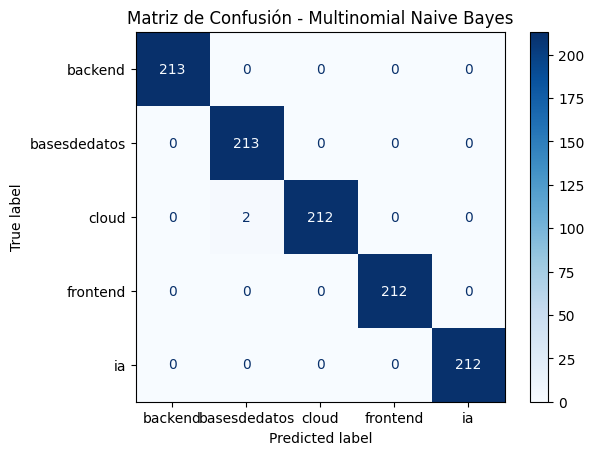

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_LR,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Multinomial Naive Bayes")

plt.show()

##Guardado de Pipeline

In [43]:
#Guardamos pipeline que usara la API
import joblib

In [44]:
joblib.dump(pipeline_LR, "pipeline_clasificador.joblib")

['pipeline_clasificador.joblib']

##Prueba de modelo

###Carga


In [45]:
modelo = joblib.load("pipeline_clasificador.joblib")

###Pruebas

In [46]:
texto = [

  "titulo Entrenamiento de un modelo de procesamiento de lenguaje natural texto Estamos limpiando un dataset utilizando la librería Pandas en Python para eliminar caracteres especiales y palabras vacias (stop words). Posteriormente, utilizaremos Scikit-Learn para vectorizar los textos mediante TF-IDF antes de alimentar una red neuronal encargada de la clasificación de texto automatizada."

]
prediccion = modelo.predict(texto)
probabilidades = modelo.predict_proba(texto)

print("Categoría predicha:", prediccion[0])
print("\nProbabilidades:")

for categoria, prob in zip(modelo.classes_, probabilidades[0]):
    print(f"{categoria}: {prob:.2%}")


Categoría predicha: ia

Probabilidades:
backend: 6.17%
basesdedatos: 6.93%
cloud: 8.62%
frontend: 5.78%
ia: 72.50%


In [47]:
texto = [

  """Título: "Administración y Optimización de Bases de Datos Relacionales En este curso se estudian los fundamentos del diseño y administración de bases de datos relacionales utilizando PostgreSQL, MySQL y Oracle Database. El contenido aborda la creación de tablas, definición de claves primarias y foráneas, restricciones de integridad, normalización de datos y modelado entidad-relación para garantizar estructuras eficientes y consistentes. Posteriormente se desarrollan consultas SQL de diferente complejidad utilizando sentencias SELECT, WHERE, GROUP BY, HAVING y ORDER BY para filtrar y organizar la información almacenada. También se profundiza en el uso de INNER JOIN, LEFT JOIN y RIGHT JOIN para relacionar múltiples tablas y obtener información consolidada de diferentes fuentes. El curso incluye la creación de índices para optimizar el rendimiento de las consultas, el uso de vistas para simplificar el acceso a la información y procedimientos almacenados para automatizar procesos repetitivos dentro del sistema gestor de bases de datos. Además, se trabajan conceptos relacionados con transacciones, propiedades ACID, control de concurrencia, bloqueo de registros y recuperación ante fallos para garantizar la integridad de la información en ambientes con múltiples usuarios. Finalmente, se realizan ejercicios de optimización de consultas mediante el análisis de planes de ejecución, ajuste de índices y monitoreo del rendimiento utilizando herramientas propias de Oracle Database y PostgreSQL"""

]
prediccion = modelo.predict(texto)
probabilidades = modelo.predict_proba(texto)

print("Categoría predicha:", prediccion[0])
print("\nProbabilidades:")

for categoria, prob in zip(modelo.classes_, probabilidades[0]):
    print(f"{categoria}: {prob:.2%}")

Categoría predicha: basesdedatos

Probabilidades:
backend: 3.83%
basesdedatos: 87.16%
cloud: 3.15%
frontend: 2.62%
ia: 3.24%


In [48]:
from google.colab import files

files.download("pipeline_clasificador.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#5.Exportando archivos a OCI

In [49]:
!pip install oci

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [50]:
import oci

##Meta data


In [51]:
import json

#Meta data


metadata = {
    "modelo": "Logistic Regression",
    "version": "1.1",
    "accuracy_cv": 0.9964,
    "accuracy_test": 0.9981,
    "categorias": [
        "backend",
        "frontend",
        "basesdedatos",
        "cloud",
        "ia"
    ]
}

with open("metadata.json", "w", encoding="utf-8") as f:
  json.dump(metadata, f, indent=4, ensure_ascii=False)

In [52]:
files.download("metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:

import oci
from google.colab import userdata
config = {
    "user": userdata.get('user'),
    "key_file":userdata.get('key_file'),
    "fingerprint": userdata.get('fingerprint'),
    "tenancy": userdata.get('tenancy'),
    "region": userdata.get('region')
}
nombre_bucket = "bucket-hackathon"
nombre_archivo= "metadata.json"

try:
    object_storage_client = oci.object_storage.ObjectStorageClient(config)
    namespace = object_storage_client.get_namespace().data

    with open(nombre_archivo, "rb") as file_data:
        response = object_storage_client.put_object(
            namespace_name=namespace,
            bucket_name=nombre_bucket,
            object_name=nombre_archivo,
            put_object_body=file_data
        )
    print(f"🚀 ¡Metadata subido con éxito a OCI Bucket '{nombre_bucket}'! Status: {response.status}")

except Exception as e:
    print(f"⚠️ No se pudo subir a OCI (Verificá tus credenciales): {e}")

🚀 ¡Metadata subido con éxito a OCI Bucket 'bucket-hackathon'! Status: 200


##Dataset Tratado

In [56]:
df.to_csv("dataset_final.csv", index=False, encoding="utf-8")

In [57]:


config = {
    "user": userdata.get('user'),
    "key_file":userdata.get('key_file'),
    "fingerprint": userdata.get('fingerprint'),
    "tenancy": userdata.get('tenancy'),
    "region": userdata.get('region')
}
nombre_bucket = "bucket-hackathon"
nombre_archivo= "dataset_final.csv"

try:
    object_storage_client = oci.object_storage.ObjectStorageClient(config)
    namespace = object_storage_client.get_namespace().data

    with open(nombre_archivo, "rb") as file_data:
        response = object_storage_client.put_object(
            namespace_name=namespace,
            bucket_name=nombre_bucket,
            object_name=nombre_archivo,
            put_object_body=file_data
        )
    print(f"🚀 ¡Dataset subido con éxito a OCI Bucket '{nombre_bucket}'! Status: {response.status}")

except Exception as e:
    print(f"⚠️ No se pudo subir a OCI (Verificá tus credenciales): {e}")

🚀 ¡Dataset subido con éxito a OCI Bucket 'bucket-hackathon'! Status: 200


In [58]:
from google.colab import files

files.download("dataset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Pipeline

In [59]:

config = {
    "user": userdata.get('user'),
    "key_file":userdata.get('key_file'),
    "fingerprint": userdata.get('fingerprint'),
    "tenancy": userdata.get('tenancy'),
    "region": userdata.get('region')
}
nombre_bucket = "bucket-hackathon"
nombre_archivo= "pipeline_clasificador.joblib"

try:
    object_storage_client = oci.object_storage.ObjectStorageClient(config)
    namespace = object_storage_client.get_namespace().data

    with open(nombre_archivo, "rb") as file_data:
        response = object_storage_client.put_object(
            namespace_name=namespace,
            bucket_name=nombre_bucket,
            object_name=nombre_archivo,
            put_object_body=file_data
        )
    print(f"🚀 ¡Pipeline subido con éxito a OCI Bucket '{nombre_bucket}'! Status: {response.status}")

except Exception as e:
    print(f"⚠️ No se pudo subir a OCI (Verificá tus credenciales): {e}")

🚀 ¡Pipeline subido con éxito a OCI Bucket 'bucket-hackathon'! Status: 200
